In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa

In [2]:
def general_plot(data, file, xlabel=None, ylabel=None, title=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax.plot(data, color="black")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    fig.savefig(
        file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

def decomp_plot(data, file):
    decomp_result = tsa.seasonal_decompose(data)
    fig = decomp_result.plot()
    axes = fig.get_axes()

    for ax in axes:
        for line in ax.get_lines():
            line.set_color("black")
    
    axes[3].get_lines()[1].set_color("black")

    axes[0].set_title(None)
    axes[0].set_ylabel("Szereg czasowy")
    axes[1].set_ylabel("Trend")
    axes[2].set_ylabel("Sezonowość")
    axes[3].set_ylabel("Reszty")
    fig.savefig(
        file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

In [3]:
monthly_data = pd.read_excel("../data/dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("../data/dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("../data/dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

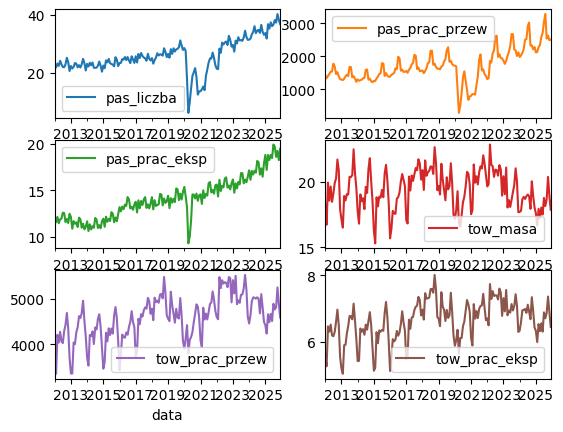

In [4]:
fig, ax = plt.subplots(3, 2)

monthly_data.plot(subplots=True, ax=ax)
plt.xlabel(None)
plt.show()

# Zmienna masa towarów w transporcie kolejowym

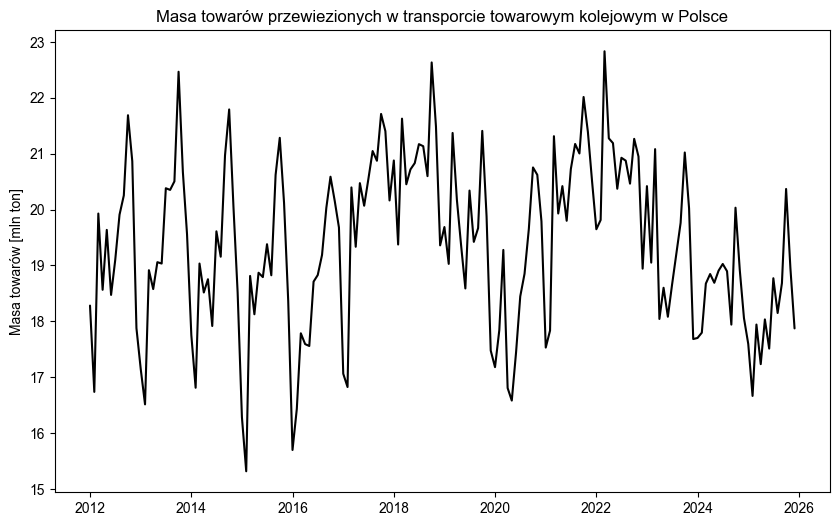

In [5]:
general_plot(
    monthly_data["tow_masa"],
    file="../figures/tow_masa.png",
    ylabel="Masa towarów [mln ton]",
    title="Masa towarów przewiezionych w transporcie towarowym kolejowym w Polsce"
)

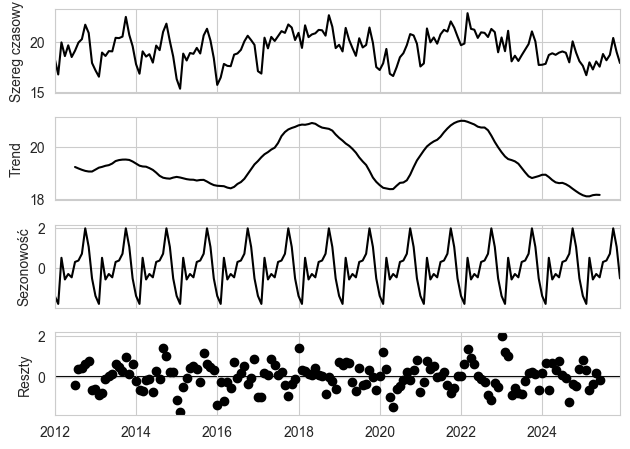

In [6]:
decomp_plot(
    monthly_data["tow_masa"],
    file="../figures/tow_masa_decomp.png"
)


# Zmienna praca przewozowa w transporcie kolejowym towarowym

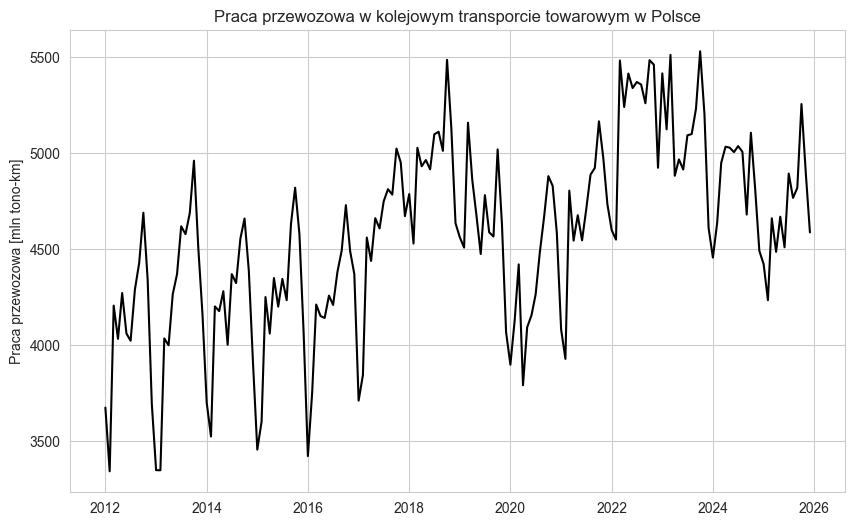

In [7]:
general_plot(
    monthly_data["tow_prac_przew"],
    file="../figures/tow_prac_przew.png",
    ylabel="Praca przewozowa [mln tono-km]",
    title="Praca przewozowa w kolejowym transporcie towarowym w Polsce"
)

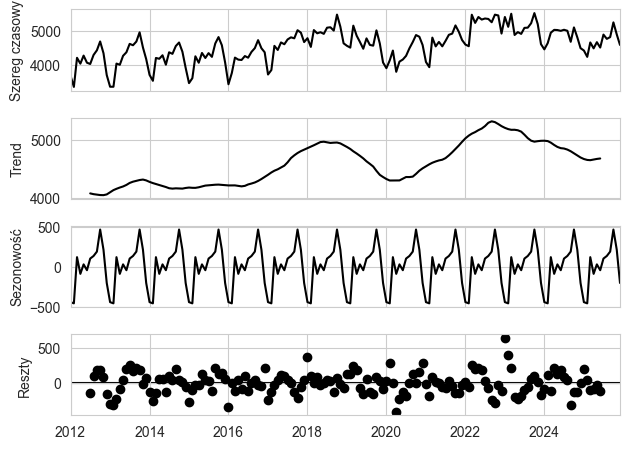

In [8]:
decomp_plot(
    monthly_data["tow_prac_przew"],
    file="../figures/tow_prac_przew_decomp.png"
)